# Task 29 – Product Basket Analysis
**Veda Technology · Data Analytics Track** · Dataset: Online Retail II · Tools: Python, Pandas

**Goal:** find which products are frequently bought together (using order IDs, no self-pairs) and turn that into recommendations.

> Put `online_retail_II.csv` in a `data/` folder next to this notebook before running.

In [1]:
import re
from pathlib import Path

import numpy as np
import pandas as pd
from scipy import sparse
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt

RAW_PATH = Path("data/online_retail_II.csv")
OUT = Path("outputs"); OUT.mkdir(exist_ok=True)
MIN_PAIR_COUNT = 100          # a pair must occur in >= 100 orders to be called "reliable"

## 1. Load the data
Online Retail II: UK online gift-ware wholesaler, Dec 2009 – Dec 2011. `Invoice` is the order ID, so one invoice = one basket. Invoice and StockCode are read as text so codes like `85123A` keep their letters.

In [2]:
df = pd.read_csv(RAW_PATH, dtype={"Invoice": str, "StockCode": str}, parse_dates=["InvoiceDate"])
log = [("Raw rows", len(df))]

## 2. Preprocessing
Every filter is logged so the row count after each step is visible. Cancellations (invoices starting with **C**), negative quantities, zero prices and non-product lines (postage, fees, carriage) are not real purchases and would create false pairs. Missing *Customer ID* is **not** a problem here because baskets are built from the order ID, so those rows are kept.

In [3]:
def step(name, mask):
    """keep rows where mask is True and log how many remain"""
    global df
    df = df[mask]
    log.append((name, len(df)))

df = df.drop_duplicates();                                   log.append(("Drop exact duplicate rows", len(df)))
step("Drop cancellations / adjustments (Invoice starts with C or A)", ~df["Invoice"].str.contains("[A-Za-z]"))
step("Keep Quantity > 0", df["Quantity"] > 0)
step("Keep Price > 0", df["Price"] > 0)

df = df.assign(StockCode=df["StockCode"].str.strip().str.upper())
step("Keep real product codes (5 digits + optional letter)", df["StockCode"].str.match(r"^\d{5}[A-Z]{0,2}$"))
step("Drop rows with missing Description", df["Description"].notna())

df = df.assign(Description=df["Description"].str.upper().str.replace(r"\s+", " ", regex=True).str.strip())
NON_PRODUCT = r"CARRIAGE|POSTAGE|DOTCOM|MANUAL|ADJUST|BANK CHARGES|AMAZON|SAMPLES?$|DISCOUNT"
step("Drop non-product lines (carriage, postage, fees...)", ~df["Description"].str.contains(NON_PRODUCT))

# One clean name per StockCode (most frequent description)
names = df.groupby("StockCode")["Description"].agg(lambda s: s.mode().iat[0])
df = df.assign(Description=df["StockCode"].map(names))
df = df.assign(Revenue=(df["Quantity"] * df["Price"]).round(2),
               Customer_ID=df["Customer ID"])
df = df.drop(columns="Customer ID")

## 3. Build baskets
One row per (order, product). Buying 12 units of a product still counts once. Orders with a single product can't form a pair and are excluded from the pair analysis.

In [4]:
# one row per (order, product): buying 12 of an item still counts as ONE appearance
baskets = df[["Invoice", "StockCode"]].drop_duplicates()
size = baskets.groupby("Invoice").size()
baskets = baskets[baskets["Invoice"].isin(size[size >= 2].index)]     # pairs need >= 2 items
log.append(("Orders with >= 2 distinct products (used for pairs)", baskets["Invoice"].nunique()))

## 4. Count product pairs
A sparse order × product matrix `X` is multiplied by its transpose to count how many orders contain each pair. Keeping only the upper triangle (`row < col`) **excludes self-pairs** (A, A) and stops (A, B) and (B, A) being counted twice. Metrics: **support** (share of orders with both), **confidence** (P(B | A)) and **lift** (how much more often than chance; >1 means a real association).

In [5]:
inv = baskets["Invoice"].astype("category")
itm = baskets["StockCode"].astype("category")
X = sparse.csr_matrix((np.ones(len(baskets), dtype=np.int32), (inv.cat.codes, itm.cat.codes)))
C = (X.T @ X).tocoo()                       # item x item co-occurrence matrix
keep = C.row < C.col                        # upper triangle only -> removes self-pairs AND mirrored duplicates
codes = itm.cat.categories
pairs = pd.DataFrame({"product_a": codes[C.row[keep]], "product_b": codes[C.col[keep]], "orders_together": C.data[keep]})

N = X.shape[0]
freq = pd.Series(np.asarray(X.sum(axis=0)).ravel(), index=codes)
pairs["count_a"] = pairs["product_a"].map(freq).values
pairs["count_b"] = pairs["product_b"].map(freq).values
pairs["support_pct"] = pairs["orders_together"] / N * 100
pairs["confidence_a_to_b"] = pairs["orders_together"] / pairs["count_a"]
pairs["confidence_b_to_a"] = pairs["orders_together"] / pairs["count_b"]
pairs["lift"] = pairs["orders_together"] * N / (pairs["count_a"] * pairs["count_b"])
pairs["desc_a"] = pairs["product_a"].map(names)
pairs["desc_b"] = pairs["product_b"].map(names)

# Flag pairs that are really the same product family (colour / design variants, shared name words)
FILLER = set("OF SET PACK WITH AND IN FOR THE A TO BOX BAG SMALL LARGE MEDIUM RED PINK BLUE GREEN WHITE BLACK YELLOW "
             "ORANGE PURPLE IVORY CREAM GREY SILVER GOLD CLEAR ASSORTED VINTAGE DESIGN COLOUR COLOURS".split())
def tokens(txt):
    return {t for t in re.findall(r"[A-Z]+", txt) if t not in FILLER and len(t) > 2}
def same_family(code_a, code_b, a, b):
    if code_a[:5] == code_b[:5]:                 # 85123A vs 85123B
        return True
    return bool(tokens(a) & tokens(b))
top_pool = pairs[pairs["orders_together"] >= MIN_PAIR_COUNT].copy()
top_pool["pair_type"] = [("Same family" if same_family(ca, cb, a, b) else "Cross-category")
                         for ca, cb, a, b in zip(top_pool["product_a"], top_pool["product_b"], top_pool["desc_a"], top_pool["desc_b"])]
pairs = pairs.merge(top_pool[["product_a", "product_b", "pair_type"]], how="left", on=["product_a", "product_b"])

## 5. Results
Pairs seen in fewer than 100 orders are treated as unreliable for lift ranking, because lift is inflated by rare products.

In [6]:
cols = ["desc_a", "desc_b", "orders_together", "support_pct", "confidence_a_to_b", "confidence_b_to_a", "lift", "pair_type"]
top_freq = pairs.sort_values("orders_together", ascending=False).head(20)[cols]
reliable = pairs[pairs["orders_together"] >= MIN_PAIR_COUNT]
top_lift = reliable.sort_values("lift", ascending=False).head(20)[cols]
top_cross = reliable[reliable["pair_type"] == "Cross-category"].sort_values("orders_together", ascending=False).head(20)[cols]
top_cross_lift = reliable[reliable["pair_type"] == "Cross-category"].sort_values("lift", ascending=False).head(20)[cols]

# Directed recommendations: "customers who buy A also buy B"
d1 = reliable.rename(columns={"desc_a": "if_customer_buys", "desc_b": "recommend", "confidence_a_to_b": "confidence"})
d2 = reliable.rename(columns={"desc_b": "if_customer_buys", "desc_a": "recommend", "confidence_b_to_a": "confidence"})
keep_cols = ["if_customer_buys", "recommend", "orders_together", "confidence", "lift", "pair_type"]
rules = pd.concat([d1[keep_cols], d2[keep_cols]])
recs = (rules[(rules["pair_type"] == "Cross-category") & (rules["confidence"] >= 0.15) & (rules["lift"] >= 2)]
        .sort_values(["confidence", "lift"], ascending=False).head(15))
bundles = (rules[(rules["pair_type"] == "Same family") & (rules["confidence"] >= 0.5)]
           .sort_values("lift", ascending=False).head(15))

for name, t in [("top_product_pairs.csv", top_freq), ("top_pairs_by_lift.csv", top_lift),
                ("top_cross_product_pairs.csv", top_cross), ("recommendations.csv", recs), ("bundle_candidates.csv", bundles)]:
    t.round(4).to_csv(OUT / name, index=False)
pairs.drop(columns="pair_type").sort_values("orders_together", ascending=False).head(5000).round(4)\
     .to_csv(OUT / "all_pairs_top5000.csv", index=False)

# cleaned dataset (compressed so it fits on GitHub)
Path("data").mkdir(exist_ok=True)
df.to_csv("data/cleaned_online_retail.csv.gz", index=False, compression="gzip")
pd.DataFrame(log, columns=["step", "rows_remaining"]).to_csv(OUT / "cleaning_log.csv", index=False)

## 6. Charts

In [7]:
def barh(t, title, fname, color):
    t = t.head(15).iloc[::-1]
    labels = (t["desc_a"].str.title().str[:36] + "  +  " + t["desc_b"].str.title().str[:36])
    fig, ax = plt.subplots(figsize=(14, 7))
    ax.barh(labels, t["orders_together"], color=color)
    for y, v in enumerate(t["orders_together"]):
        ax.text(v + 8, y, f"{v:,}", va="center", fontsize=9)
    ax.set_title(title, loc="left", fontsize=13, fontweight="bold")
    ax.set_xlabel("Orders containing both products")
    for s in ("top", "right"): ax.spines[s].set_visible(False)
    plt.tight_layout(); fig.savefig(OUT / fname, dpi=150); plt.close(fig)

barh(top_freq, "Top 15 product pairs by number of orders", "chart_top_pairs.png", "#2b6cb0")
barh(top_cross, "Top 15 cross-category pairs (unrelated product families)", "chart_top_cross_pairs.png", "#2f855a")

fig, ax = plt.subplots(figsize=(9, 6))
ax.scatter(reliable["orders_together"], reliable["lift"], s=8, alpha=.35, color="#2b6cb0")
ax.set_xscale("log"); ax.set_yscale("log")
ax.set_xlabel("Orders together (log)"); ax.set_ylabel("Lift (log)")
ax.set_title("Support vs lift for reliable pairs", loc="left", fontweight="bold")
ax.axhline(1, color="grey", lw=.8, ls="--")
for s in ("top", "right"): ax.spines[s].set_visible(False)
plt.tight_layout(); fig.savefig(OUT / "chart_support_vs_lift.png", dpi=150); plt.close(fig)

## 7. Summary tables

In [8]:
pd.set_option("display.width", 250, "display.max_colwidth", 40)
print(pd.DataFrame(log, columns=["step", "rows_remaining"]).to_string(index=False))
print(reliable["pair_type"].value_counts().to_string())
print(f"\nOrders analysed: {N:,} | distinct products: {len(codes):,} | unique pairs: {len(pairs):,} | reliable pairs: {len(reliable):,}")
for t, h in [(top_freq, "TOP PAIRS BY FREQUENCY"), (top_cross, "TOP CROSS-CATEGORY PAIRS"), (top_cross_lift, "TOP CROSS-CATEGORY BY LIFT"), (recs, "RECOMMENDATIONS (cross-category)"), (bundles, "BUNDLE CANDIDATES (same family)")]:
    print(f"\n== {h} ==\n", t.round(3).to_string(index=False))

                                                         step  rows_remaining
                                                     Raw rows         1067371
                                    Drop exact duplicate rows         1033036
Drop cancellations / adjustments (Invoice starts with C or A)         1013926
                                            Keep Quantity > 0         1010533
                                               Keep Price > 0         1007912
         Keep real product codes (5 digits + optional letter)         1003214
                           Drop rows with missing Description         1003214
          Drop non-product lines (carriage, postage, fees...)         1002991
          Orders with >= 2 distinct products (used for pairs)           36302
pair_type
Cross-category    24149
Same family        4613

Orders analysed: 36,302 | distinct products: 4,694 | unique pairs: 5,309,988 | reliable pairs: 28,762

== TOP PAIRS BY FREQUENCY ==
                            d

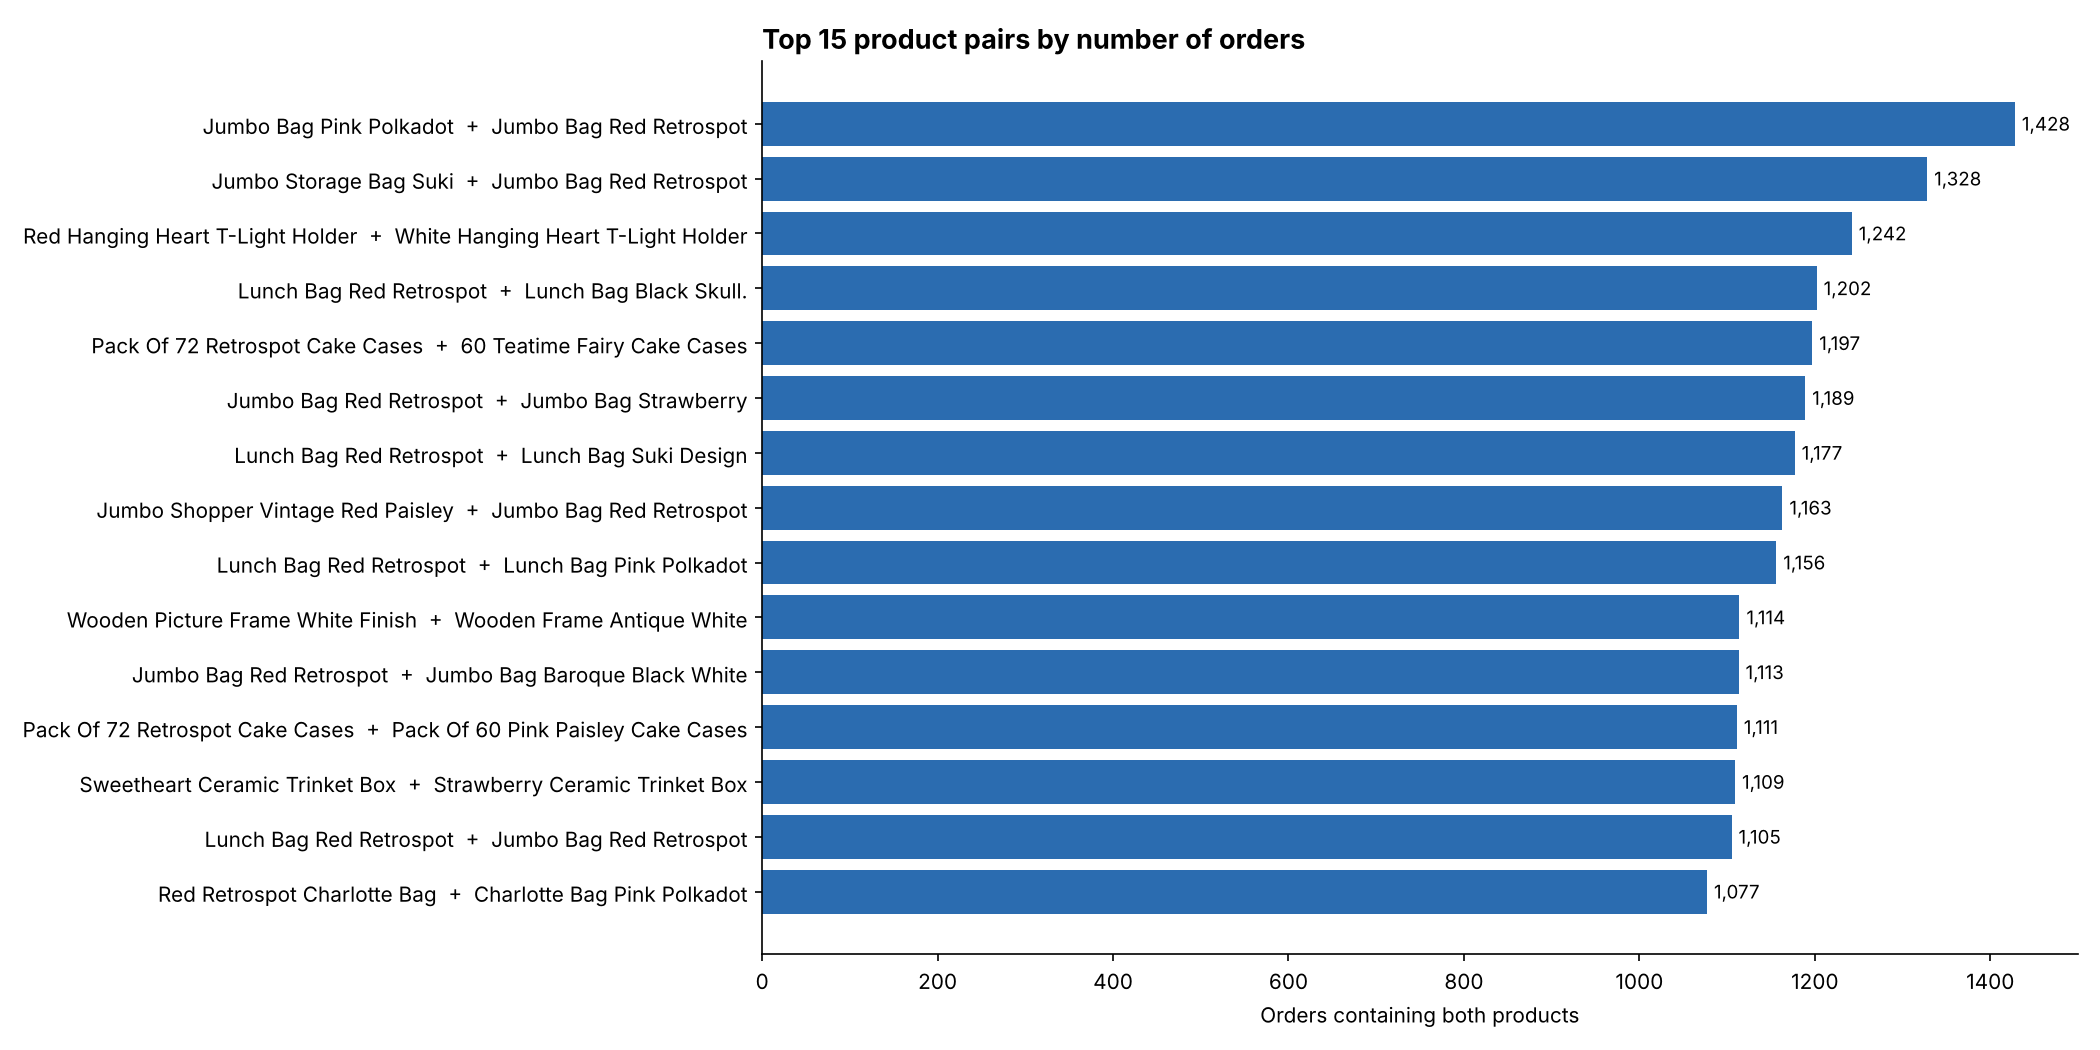

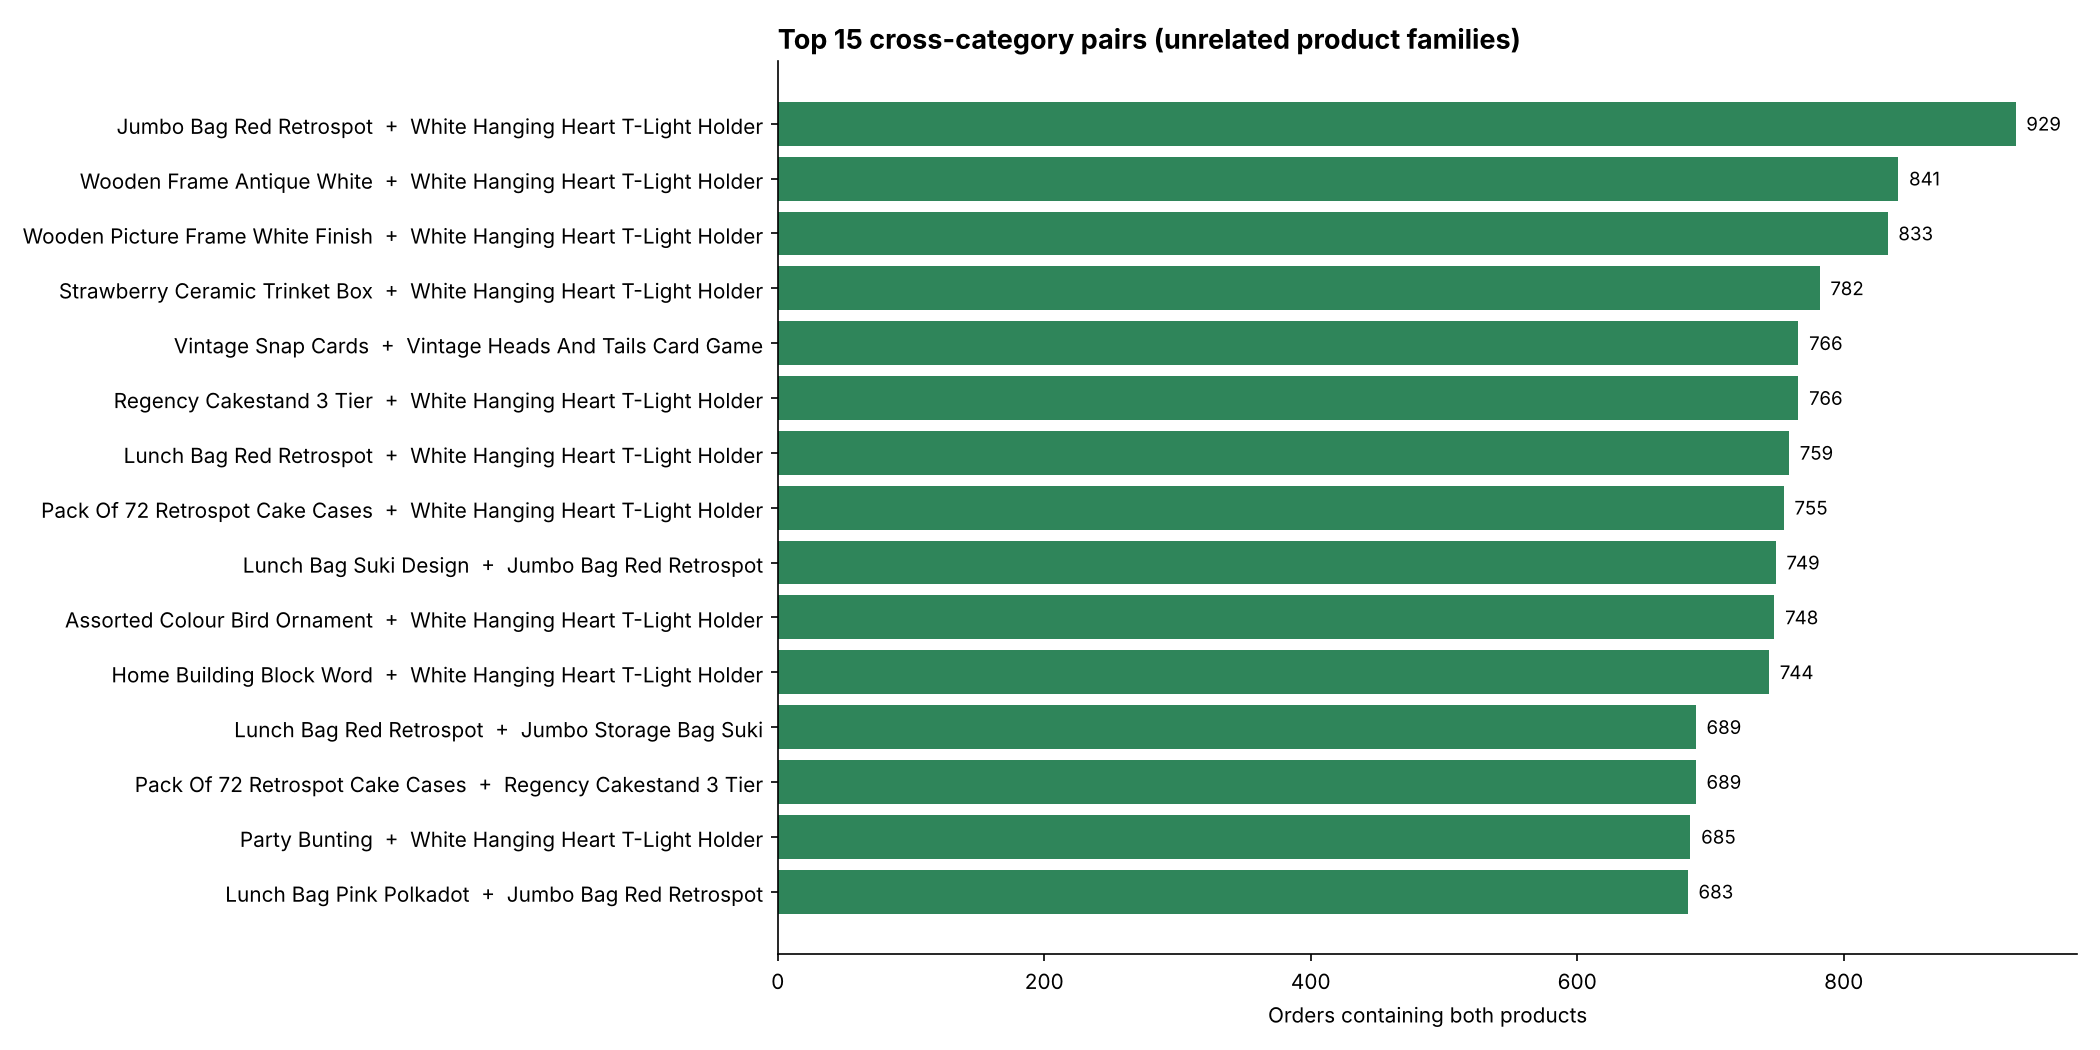

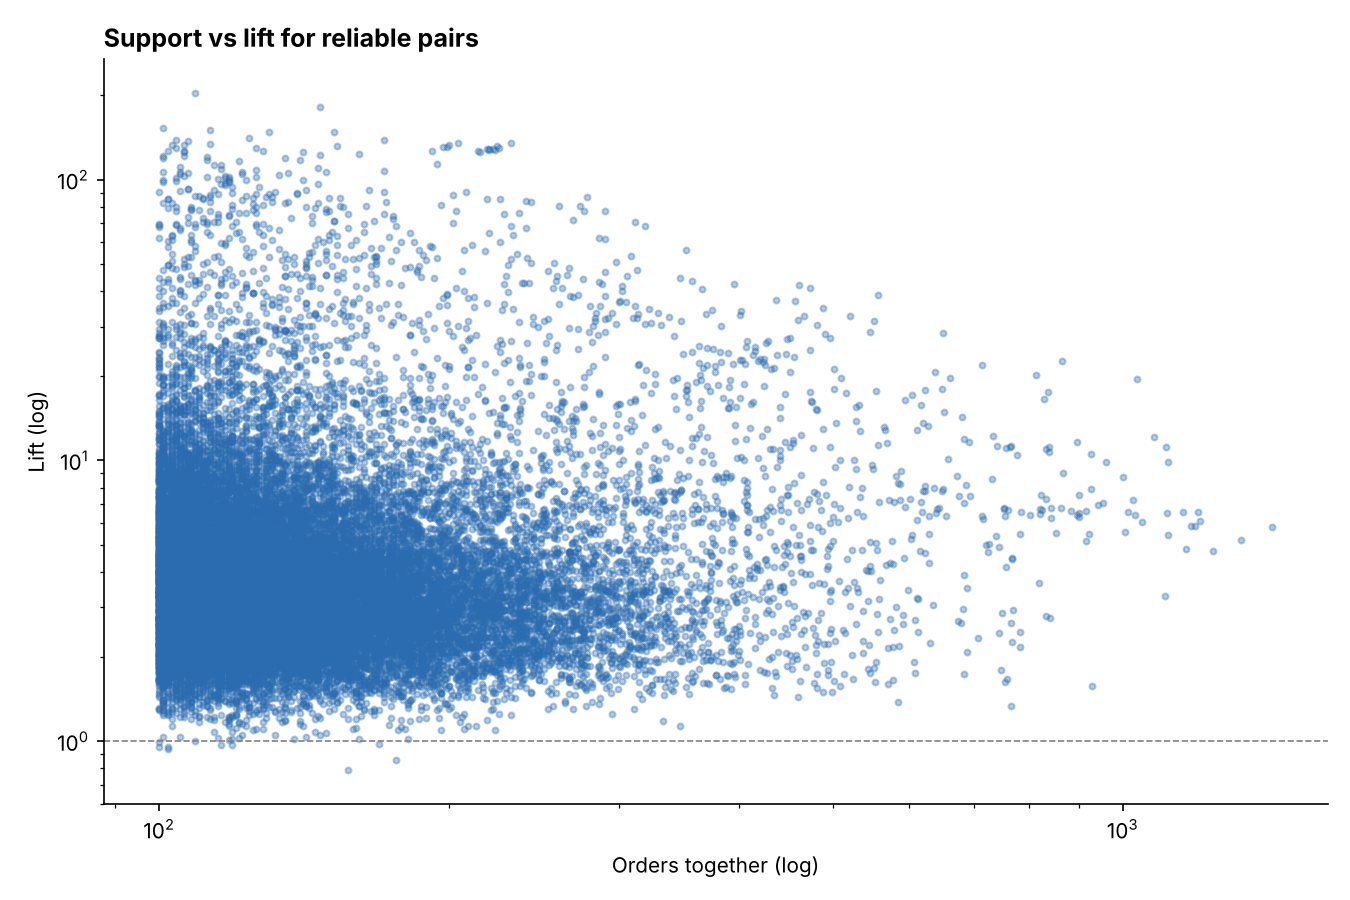

In [9]:
from IPython.display import Image, display
for f in ['chart_top_pairs.png','chart_top_cross_pairs.png','chart_support_vs_lift.png']:
    display(Image(OUT/f))

## 8. Key findings and recommendations

**Data used:** 1,067,371 raw rows → 1,002,991 clean rows (94%). 36,302 orders with ≥ 2 products, 4,694 distinct products, 5.3 million unique pairs; 28,762 pairs appear in ≥ 100 orders and were treated as reliable.

### What the pairs show
1. **The most frequent pair is two Jumbo Bags** – *Pink Polkadot* + *Red Retrospot*: 1,428 orders (3.9% of all multi-item orders), lift 5.8. Most of the top-20 pairs are colour/design variants of one product line (Lunch Bags, Jumbo Bags, Regency Teacups, Charlotte Bags). This is a **wholesale** customer base that stocks several designs at once.
2. **Complementary sets have the highest lift.** *Set/6 Fruit Salad Paper Cups* + *Plates* (lift 203, 80% confidence), *Cast Iron Garden Fork* + *Trowel* (lift 181, 86%), *Dolly Girl Bowl* + *Cup* (lift 148), *Green* + *Roses Regency Teacup and Saucer* (1,034 orders, lift 19.6, ~75% both ways).
3. **True cross-category pairs exist too:** *Vintage Snap Cards* + *Vintage Heads and Tails Card Game* (766 orders, lift 11.2), *Boys/Girls Seaside Bucket* + *Red Metal Beach Spade* (lift 41, ~53%), *Painted Metal Pears* → *Assorted Colour Bird Ornament* (529 orders, 72% confidence, lift 9.3), *Pack of 72 Retrospot Cake Cases* + *Regency Cakestand 3 Tier* (689 orders, lift 2.1).
4. **Popularity is not association.** *White Hanging Heart T-Light Holder* appears in many of the most frequent cross-category pairs, but with low lift (1.3–2.8). It is in lots of baskets simply because it is the best seller. Lift separates real affinity from popularity.
5. **Low-priced add-ons:** *Beaded Crystal Heart on Stick* is bought with a wide range of items (stationery sets, bibs, tape measures, candles) at lift 35–54, which fits an impulse add-on.

### Recommendations
| # | Action | Evidence |
|---|---|---|
| 1 | **Bundle same-family sets** (Fruit Salad cups + plates, Garden fork + trowel, Dolly Girl / Spaceboy kids' ranges, Regency teacup colours) as "Buy the set" offers | 60–86% confidence, lift 100+ |
| 2 | **Show "Customers also bought" on product pages** using the cross-category rules (`recommendations.csv`) | e.g. Painted Metal Pears → Bird Ornament, 72% |
| 3 | **Place add-on items at checkout** (Beaded Crystal Hearts, Gold Mini Tape Measure) | lift 35–54 with many products |
| 4 | **Stock and promote together:** Jumbo Bag Red Retrospot with Jumbo Storage Bag Suki and Pink Polkadot; Cake Cases with the Regency Cakestand; Seaside Bucket with Beach Spade, especially before summer | 1,000+ joint orders, or lift 40+ |
| 5 | **Don't use raw frequency alone** to choose cross-sell items. Best sellers like the White Hanging Heart holder pair with everything. Rank by lift with a minimum order count | lift 1.3–2.8 |

### Limitations
- Association is not causation: pairs show co-purchase, not that one product drives the other.
- Customers are mostly wholesale buyers, so patterns may differ for individual shoppers.
- The "same family / cross-category" label is a name-matching heuristic, so a few pairs may be mislabelled.
- Lift is unstable for rare items; the ≥ 100 order threshold is a judgement call (`MIN_PAIR_COUNT`).
- Seasonality (Q4 Christmas peak) and country differences were not analysed; a good next step.
